<a href="https://colab.research.google.com/github/Akshat-Sharma2005/House-price-predictor/blob/master/XG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Prices**

## Importing The Libraries

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector, ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Importing the Dataset

In [24]:
dataset = pd.read_csv('train.csv')
X = dataset.drop(columns=['Id', 'SalePrice'])
y = dataset['SalePrice']

In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Dividing the Dataset into Categorical and Numerical

In [26]:
numerical_cols = make_column_selector(dtype_include='number')
categorical_cols = make_column_selector(dtype_exclude='number')

## Splitting the dataset into the Training set and Test set

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Pipelines for Numerical and Categorical Columns

In [28]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## Applying Column Tramsformer

In [29]:
preprocessor = ColumnTransformer([
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])
preprocessor.fit_transform(X_train)
preprocessor.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23066 stored elements and shape (292, 285)>

## Main Pipeline

In [30]:


xgb_pipeline = Pipeline ([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(reg_alpha=1, reg_lambda=1, random_state=42))
])

## Target Wrapper

In [31]:
xgb_final_model = TransformedTargetRegressor(
    regressor=xgb_pipeline,
    func = np.log1p,
    inverse_func = np.expm1
)


## Hyperparameter Grid

In [32]:
param_grid = [
    {
    'regressor__model__n_estimators': [50, 75, 100, 125, 150],
    'regressor__model__max_depth': [None, 5, 10],
    'regressor__model__learning_rate': [0.05, 0.01, 0.1]

    }
]

## Model Selection

### K-Fold

In [33]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Grid Search

In [34]:
grid = GridSearchCV(
    estimator=xgb_final_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)

## **Training The Model**

In [35]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('preprocessing',
                                                                             ColumnTransformer(transformers=[('num',
                                                                                                              Pipeline(steps=[('imputer',
                                                                                                                               SimpleImputer(strategy='median')),
                                                                                                                              ('scalar',
                                                                                                                               StandardScaler())]),
                                                                                                              <sklearn.compose._column_tran...
                                                                                          max_leaves=None,
                                                                                          min_child_weight=None,
                                                                                          missing=nan,
                                                                                          monotone_constraints=None,
                                                                                          multi_strategy=None,
                                                                                          n_estimators=None,
                                                                                          n_jobs=None,
                                                                                          num_parallel_tree=None, ...))])),
             n_jobs=-1,
             param_grid=[{'regressor__model__learning_rate': [0.05, 0.01, 0.1],
                          'regressor__model__max_depth': [None, 5, 10],
                          'regressor__model__n_estimators': [50, 75, 100, 125,
                                                             150]}],
             scoring='r2', verbose=2)

In [36]:
print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)



Best Parameters:
{'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 5, 'regressor__model__n_estimators': 125}

Best Cross Validation Score:
0.8436341524124146


## Test Predictions

In [37]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [38]:

# 1. Calculate the metrics on the original scale
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # RMSE is just the square root of MSE
r2 = r2_score(y_test, y_pred)

# 2. Print the evaluation report
print("================ MODEL EVALUATION REPORT ================")
print(f"Mean Absolute Error (MAE):     ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):   ${rmse:,.2f}")
print(f"R-squared (R2 Score):            {r2:.4f}")
print("=========================================================")

# 3. Quick Interpretation Check
if r2 <= 0:
    print(
        "💡 Insight: Your R2 score is 0 or negative. This means your model is \n"
        "   performing worse than a simple baseline that just guesses the average."
    )
else:
    print(
        f"💡 Insight: Your model explains {r2*100:.2f}% of the variance in the Dataset."
    )

================ MODEL EVALUATION REPORT ================
Mean Absolute Error (MAE):     $16,393.43
Root Mean Squared Error (RMSE):   $29,665.44
R-squared (R2 Score):            0.8853
💡 Insight: Your model explains 88.53% of the variance in the Dataset.


##**Checking the Data on new records**

In [39]:

test_df = pd.read_csv('test.csv')

X_actual_test = test_df[list(X.columns)]

best_xgb_model = grid.best_estimator_

xgb_predictions = best_xgb_model.predict(X_actual_test)

xgb_submission_df = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': xgb_predictions
})

xgb_submission_df.to_csv('submission_xgboost.csv', index=False)
print("Success!")

Success!


In [40]:
xgb_submission_df.head()

,Id,SalePrice
0,1461,123101.632812
1,1462,158182.781250
2,1463,188168.718750
3,1464,203355.593750
4,1465,198100.000000


## Exporting

In [41]:
import joblib
fitted_best_model = grid.best_estimator_
joblib.dump(fitted_best_model, 'house_price_xgb_model.pkl')
print("Success! model has been compiled.")

Success! model has been compiled.


## **Visualizing**

/tmp/ipykernel_9162/408728758.py:29: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


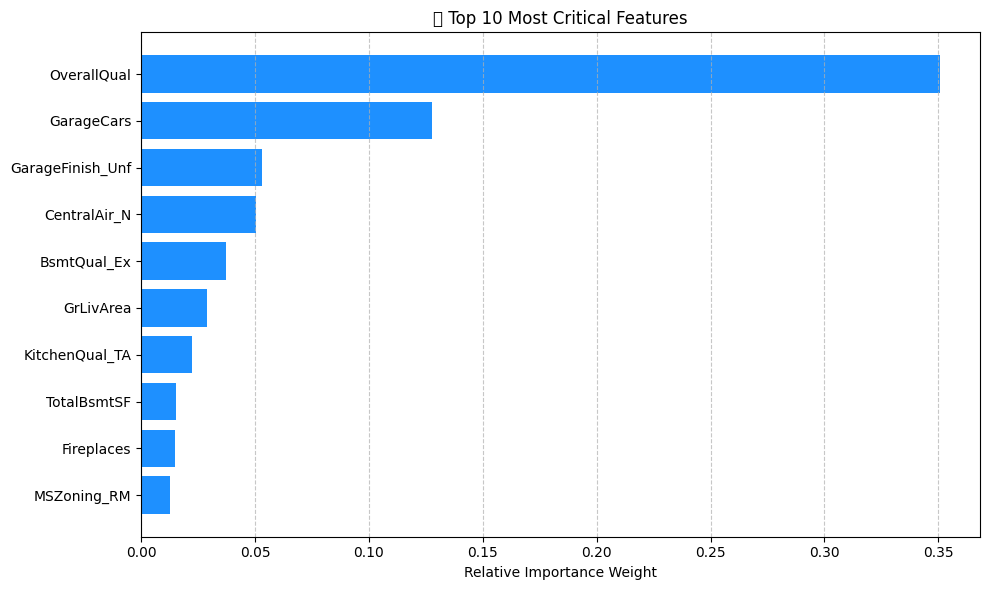


📋 Top 10 features :
     OverallQual
      GarageCars
GarageFinish_Unf
    CentralAir_N
     BsmtQual_Ex
       GrLivArea
  KitchenQual_TA
     TotalBsmtSF
      Fireplaces
     MSZoning_RM


In [42]:
import matplotlib.pyplot as plt

best_pipeline = grid.best_estimator_.regressor_
preprocessor = best_pipeline.named_steps['preprocessing']
xgb_model = best_pipeline.named_steps['model']

actual_num_cols = list(numerical_cols(X_train))
actual_cat_cols = list(categorical_cols(X_train))

cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = list(cat_encoder.get_feature_names_out(actual_cat_cols))

all_feature_names = actual_num_cols + encoded_cat_features

importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the Top 10 Most Important Features
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'].head(10)[::-1],
         feature_imp_df['Importance'].head(10)[::-1],
         color='dodgerblue')
plt.xlabel('Relative Importance Weight')
plt.title('🔥 Top 10 Most Critical Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n📋 Top 10 features :")
print(feature_imp_df['Feature'].head(10).to_string(index=False))